## Radiative Heating and $\omega$ Relation

### Import package

In [9]:
import os
import sys

import numpy as np
import netCDF4 as nc

from pathlib import Path
from typing import Tuple
from datetime import datetime
from scipy.signal import detrend

from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm

sys.path.append("/home/b11209013/Manuscript_Prep/KW_CRI/src")
import spectrum

### Helper functions

In [10]:
def convert_time(time_variable: nc.Variable) -> np.ndarray:
    """Return a netCDF time coordinate as YYYY-MM-DD strings."""
    dates = nc.num2date(
        time_variable[:],
        units=time_variable.units,
        calendar=getattr(time_variable, "calendar", "standard"),
    )
    return np.asarray([date.strftime("%Y-%m-%d") for date in dates])


def as_float_array(values: np.ndarray) -> np.ndarray:
    """Convert a netCDF array to float and replace masked values by NaN."""
    masked_values = np.ma.asarray(values, dtype=np.float64)
    return np.asarray(masked_values.filled(np.nan))


### Configuration and data loading

In [11]:
DATA_PATH = Path("/data92/b11209013")
START_DATE = datetime(2006, 1, 1).strftime("%Y-%m-%d")
END_DATE = datetime(2018, 1, 1).strftime("%Y-%m-%d")
LATITUDE_BOUNDS = (-5.0, 5.0)

# Longwave radiative heating
with nc.Dataset(DATA_PATH / "CERES" / "column_LW_rm3harm.nc") as dataset:
    radiative_dates = convert_time(dataset.variables["time"])
    radiative_latitude = as_float_array(dataset.variables["lat"][:])
    radiative_longitude = as_float_array(dataset.variables["lon"][:])
    radiative_latitude_mask = (
        (radiative_latitude >= LATITUDE_BOUNDS[0])
        & (radiative_latitude <= LATITUDE_BOUNDS[1])
    )
    lw_heating = as_float_array(
        dataset.variables["column_LW"][:, radiative_latitude_mask, :]
    )

# Shortwave radiative heating
with nc.Dataset(DATA_PATH / "CERES" / "column_SW_rm3harm.nc") as dataset:
    shortwave_dates = convert_time(dataset.variables["time"])
    sw_heating = as_float_array(
        dataset.variables["column_SW"][:, radiative_latitude_mask, :]
    )

# Precipitation
with nc.Dataset(DATA_PATH / "ERA5_GRIB" / "Data" / "regrid" /"W.nc") as dataset:

    W_latitude = as_float_array(dataset.variables["lat"][:])
    W_longitude = as_float_array(dataset.variables["lon"][:])
    W_latitude_mask = (
        (W_latitude >= LATITUDE_BOUNDS[0])
        & (W_latitude <= LATITUDE_BOUNDS[1])
    )
    W_plev = as_float_array(dataset.variables["plev"][:])
    W = as_float_array(
        dataset.variables["W"][
            :, :, W_latitude_mask, :
        ]
    )

nt, nz, ny, nx = W.shape

### Project the $\omega$ into the first and second baroclinic mode

In [12]:
def calc_EOF(
        data: np.ndarray,
        sample_axis: int,
        n_components: int
) -> Tuple[np.ndarray, ...]:

    _, n_sample = data.shape # assign shape

    # remove mean
    data_anom: np.ndarray = data - np.nanmean(data, axis=sample_axis, keepdims=True)

    # calculate covariance matrix
    cov: np.ndarray = (data_anom @ data_anom.T) / n_sample

    # calculate eigenvalue and eigenvector
    eigvals, eigvecs = np.linalg.eig(cov)

    # select n_component
    select_eigvecs: np.ndarray = eigvecs[:, :n_components]

    # Normalize eigenvectors
    EOFs: np.ndarray = select_eigvecs / np.sum(select_eigvecs, axis=0)

    # Calculate principle components
    PCs: np.ndarray = np.linalg.inv(EOFs.T @ EOFs) @ (EOFs.T @ data_anom)

    return EOFs, PCs



### Preprocessing and segmentation

In [13]:
CHUNK_SIZE = 96
CHUNK_OVERLAP = CHUNK_SIZE // 2
hann_window = np.hanning(CHUNK_SIZE)

qr_heating = lw_heating + sw_heating

# calculate anomaly
qr_heating -= np.nanmean(qr_heating, axis=(0, -1), keepdims=True)
lw_heating -= np.nanmean(lw_heating, axis=(0, -1), keepdims=True)
sw_heating -= np.nanmean(sw_heating, axis=(0, -1), keepdims=True)
W          -= np.nanmean(W         , axis=(0, -1), keepdims=True)

# Calculate EOFs and PCs
W_EOF, W_PCs = calc_EOF(
    W.transpose(1, 0, 2, 3).reshape(nz, -1),
    sample_axis=1,
    n_components=2
)

W1: np.ndarray = -W_PCs[0].reshape(nt, ny, nx)
W2: np.ndarray = -W_PCs[1].reshape(nt, ny, nx)

# symmetrizing the data
symmetric_fields = {
    "QR": spectrum.symm_asym(qr_heating, lat_axis=1)[0],
    "LW": spectrum.symm_asym(lw_heating, lat_axis=1)[0],
    "SW": spectrum.symm_asym(sw_heating, lat_axis=1)[0],
    "W1": spectrum.symm_asym(W1, lat_axis=1)[0],
    "W2": spectrum.symm_asym(W2, lat_axis=1)[0],
}

# chunking data
chunking_fields = {
    key: spectrum.chunking(
        symmetric_fields[key],
        time_axis=0,
        window_size=CHUNK_SIZE,
        overlap_size=CHUNK_OVERLAP
        )
    for key in symmetric_fields.keys()
}

n_segments, _, n_latitudes, n_longitudes = chunking_fields["QR"].shape
print(f"Windowed chunk shape: {chunking_fields['QR'].shape}")

Windowed chunk shape: (90, 96, 10, 360)


### Cross-spectral analysis

In [14]:
frequencies = np.fft.fftfreq(CHUNK_SIZE, d=1.0)
zonal_wavenumbers = np.fft.fftfreq(
    n_longitudes, d=1.0 / n_longitudes
)

source_chunks = {
    name: chunking_fields[name]
    for name in ("QR", "LW", "SW")
}

# Calculate one latitude-mean estimate for every time segment.
W1cross_spectrum, power_spectrum, W1_power_spectrum = (
    spectrum.calculate_segment_spectra(
        source_chunks=source_chunks,
        reference_chunks=chunking_fields["W1"],
        window_energy=float(np.mean(hann_window**2)),
    )
)

W2cross_spectrum, power_spectrum, W2_power_spectrum = (
    spectrum.calculate_segment_spectra(
        source_chunks=source_chunks,
        reference_chunks=chunking_fields["W2"],
        window_energy=float(np.mean(hann_window**2)),
    )
)

# Average across segments only; latitude was averaged in the function.
W1_mean_cross_spectrum = {
    name: np.nanmean(values, axis=0)
    for name, values in W1cross_spectrum.items()
}

W2_mean_cross_spectrum = {
    name: np.nanmean(values, axis=0)
    for name, values in W2cross_spectrum.items()
}

mean_power_spectrum = {
    name: np.nanmean(values, axis=0)
    for name, values in power_spectrum.items()
}

mean_W1_power_spectrum = np.nanmean(
    W1_power_spectrum, axis=0
)

mean_W2_power_spectrum = np.nanmean(
    W2_power_spectrum, axis=0
)

# Form coherence from averaged spectra. Per-periodogram coherence is one.
W1_coherence_squared = {
    name: spectrum.calculate_squared_coherence(
        mean_cross_spectrum=W1_mean_cross_spectrum[name],
        mean_source_power=mean_power_spectrum[name],
        mean_reference_power=mean_W1_power_spectrum,
    )
    for name in source_chunks
}

W2_coherence_squared = {
    name: spectrum.calculate_squared_coherence(
        mean_cross_spectrum=W2_mean_cross_spectrum[name],
        mean_source_power=mean_power_spectrum[name],
        mean_reference_power=mean_W2_power_spectrum,
    )
    for name in source_chunks
}

W1_cospectrum = {
    name: values.real for name, values in W1_mean_cross_spectrum.items()
}
W1_quadrature_spectrum = {
    name: values.imag for name, values in W1_mean_cross_spectrum.items()
}
W1_phase_degrees = {
    name: np.rad2deg(np.angle(values))
    for name, values in W1_mean_cross_spectrum.items()
}

W2_cospectrum = {
    name: values.real for name, values in W2_mean_cross_spectrum.items()
}
W2_quadrature_spectrum = {
    name: values.imag for name, values in W2_mean_cross_spectrum.items()
}
W2_phase_degrees = {
    name: np.rad2deg(np.angle(values))
    for name, values in W2_mean_cross_spectrum.items()
}


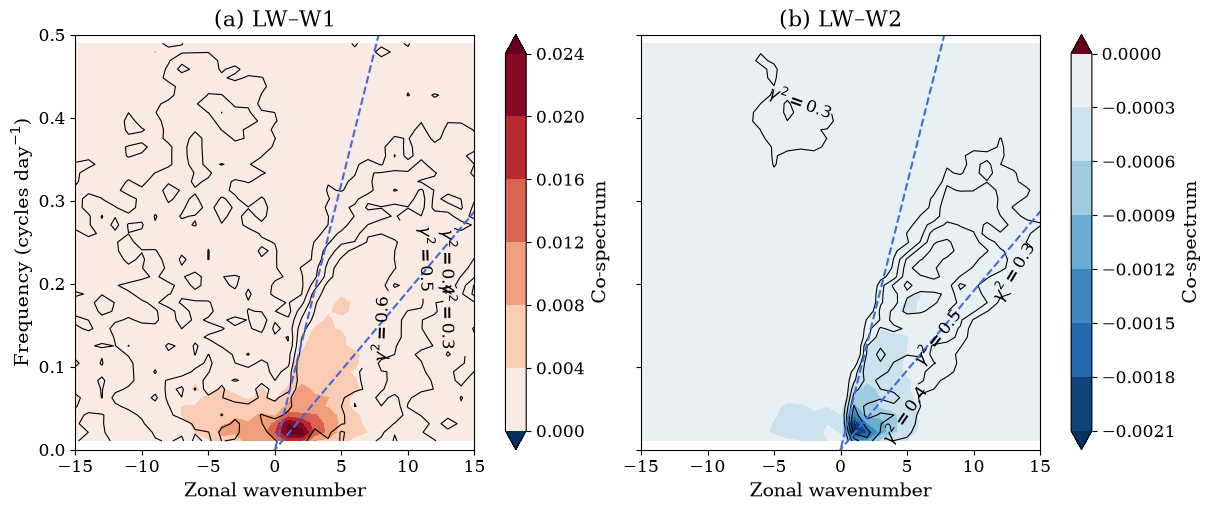

In [17]:
SOURCE_NAME = "LW"
COHERENCE_LEVELS = (0.3, 0.4, 0.5, 0.6, 0.8)

shifted_wavenumbers = np.fft.fftshift(zonal_wavenumbers)
shifted_frequencies = np.fft.fftshift(frequencies)
shifted_W1_cospectrum = np.fft.fftshift(
    W1_cospectrum[SOURCE_NAME], axes=(0, 1)
)
shifted_W1_coherence = np.fft.fftshift(
    W1_coherence_squared[SOURCE_NAME], axes=(0, 1)
)
shifted_W2_cospectrum = np.fft.fftshift(
    W2_cospectrum[SOURCE_NAME], axes=(0, 1)
)
shifted_W2_coherence = np.fft.fftshift(
    W2_coherence_squared[SOURCE_NAME], axes=(0, 1)
)

# Retain positive temporal frequencies for the conventional display.
positive_frequency = shifted_frequencies > 0
frequency_display = shifted_frequencies[positive_frequency]
W1_cospectrum_display = shifted_W1_cospectrum[positive_frequency, :]
W1_coherence_display = shifted_W1_coherence[positive_frequency, :]

W2_cospectrum_display = shifted_W2_cospectrum[positive_frequency, :]
W2_coherence_display = shifted_W2_coherence[positive_frequency, :]

shading_levels = np.linspace(0, 0.1, 11)


plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)

panel_data = (
    ("W1", W1_cospectrum_display, W1_coherence_display),
    ("W2", W2_cospectrum_display, W2_coherence_display),
)
equivalent_depths = (8, 90)
earth_radius = 6.371e6
seconds_per_day = 86400.0

figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for panel_label, axis, (mode, cospectrum, coherence) in zip(
    ("a", "b"), axes, panel_data
):
    shading = axis.contourf(
        shifted_wavenumbers,
        frequency_display,
        cospectrum,
        norm=TwoSlopeNorm(0.0),
        cmap="RdBu_r",
        extend="both",
    )

    finite_coherence = coherence[np.isfinite(coherence)]
    available_levels = []
    if finite_coherence.size:
        available_levels = [
            level
            for level in COHERENCE_LEVELS
            if finite_coherence.min() < level < finite_coherence.max()
        ]
    if available_levels:
        coherence_contours = axis.contour(
            shifted_wavenumbers,
            frequency_display,
            coherence,
            levels=available_levels,
            colors="black",
            linewidths=0.8,
        )
        axis.clabel(
            coherence_contours,
            fmt=lambda value: rf"$\gamma^2={value:.1f}$",
            fontsize=12,
            inline=True,
        )

    for depth in equivalent_depths:
        dispersion_frequency = (
            np.sqrt(9.81 * depth)
            * seconds_per_day
            / (2 * np.pi * earth_radius)
            * shifted_wavenumbers
        )
        axis.plot(
            shifted_wavenumbers,
            dispersion_frequency,
            color="royalblue",
            linestyle="--",
        )

    axis.set(
        xlim=(-15, 15),
        ylim=(0, 0.5),
        xlabel="Zonal wavenumber",
        title=f"({panel_label}) {SOURCE_NAME}–{mode}",
    )
    colorbar = figure.colorbar(shading, ax=axis, label="Co-spectrum")
    # colorbar.set_ticks(shading_levels[::2])

axes[0].set_ylabel("Frequency (cycles day$^{-1}$)")

plt.savefig(f"/home/b11209013/Manuscript_Prep/KW_CRI/Figure/Qr_W/{SOURCE_NAME}.png", dpi=600, bbox_inches="tight")